### **5. PATSTĀVĪGAIS DARBS. Klasterizācija un modeļu novērtēšana**

# A daļa: Klasterizācija

## 1. uzdevums. Sagatavo datus klasterizācijai


### 1.1. Ielādē un sagatavo datus

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Ielādē 2. nedēļā sagatavoto tīro datu kopu
df = pd.read_csv('../week2/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")


Datu kopa: 12330 rindas, 30 kolonnas


### 1.2. Izvēlies features klasterizācijai

In [2]:
# Izvēlamies iezīmes, kas raksturo klientu sesiju
cluster_features = ['Administrative_Duration', 'Informational_Duration',
                     'ProductRelated_Duration', 'BounceRates', 
                    'ExitRates',
                     'PageValues']

X_cluster = df[cluster_features].copy()
print(f"Klasterizācijai izmantojam {X_cluster.shape[1]} iezīmes:")
print(cluster_features)


Klasterizācijai izmantojam 6 iezīmes:
['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']


**Iezīmes klāsterizācijai**

Izvēlētās klasterizācijas iezīmes ir pamatotas ar e‑komercijas biznesa kontekstu, jo tās raksturo lietotāju uzvedību sesijas laikā – laiku, kas pavadīts dažāda veida lapās (`Administrative_Duration`, `Informational_Duration`, `ProductRelated_Duration`), lietotāja iesaistes kvalitāti (`BounceRates`, `ExitRates`) un tiešo biznesa vērtību (`PageValues`). Šāds iezīmju kopums ļauj segmentēt lietotājus pēc viņu intereses,
iesaistes un potenciālās komerciālās vērtības, kas ir būtiski klientu segmentācijas uzdevumos.

Visas izvēlētās iezīmes tika normalizētas, izmantojot `StandardScaler`, jo K‑Means klasterizācijas algoritms balstās uz Eiklīda attālumiem. Bez normalizācijas iezīmes ar lielāku skaitlisko mērogu, piemēram, `ProductRelated_Duration`, dominētu attāluma aprēķinos un izkropļotu klasterizācijas rezultātus. Normalizācija nodrošina, ka katra iezīme klasterizācijā piedalās vienlīdzīgi un klasteri tiek veidoti, balstoties uz reālām lietotāju uzvedības atšķirībām, nevis datu mēroga nesabalansētību.

Līdz ar to gan iezīmju izvēle, gan normalizācijas pielietošana ir metodoloģiski korekta un sniedz stabilu pamatu interpretējamu un biznesa ziņā nozīmīgu klasteru iegūšanai.

### 1.3. Normalizē datus

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Pārvēršam atpakaļ uz DataFrame ērtākai darbībai
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
print("Pēc normalizācijas:")
print(X_scaled_df.describe().round(2))



Pēc normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                      0.00                   -0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.41                   -0.24   
75%                       0.07                   -0.24   
max                      18.77                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                     -0.00        -0.00       0.00        0.00  
std                       1.00         1.00       1.00        1.00  
min                      -0.62        -0.46      -0.89       -0.32  
25%                      -0.53        -0.46      -0.59       -0.32  
50%                      -0.31        -0.39

**Kāpēc normalizācija ir svarīga klasterizācijā?**

K‑Means algoritms balstās uz attālumu aprēķiniem starp datu punktiem. Ja izmantotās iezīmes ir dažādos mērogos, piemēram, `ProductRelated_Duration` un `BounceRates`, tad lielāka mēroga iezīmes dominētu attāluma aprēķinā un klasterizācijas rezultāts būtu metodoloģiski nepareizs.

Izmantojot `StandardScaler`, visas iezīmes tiek pārveidotas ar vidējo vērtību 0 un standartnovirzi 1, nodrošinot, ka katra iezīme klasterizācijā piedalās vienlīdzīgi. Bez normalizācijas iegūtie klasteri vairāk atspoguļotu mērogu atšķirības, nevis patiesas klientu uzvedības līdzības.

## 2. uzdevums. Atrod optimālo klasteru skaitu (Elbow Method)

### 2.1. Elbow metode

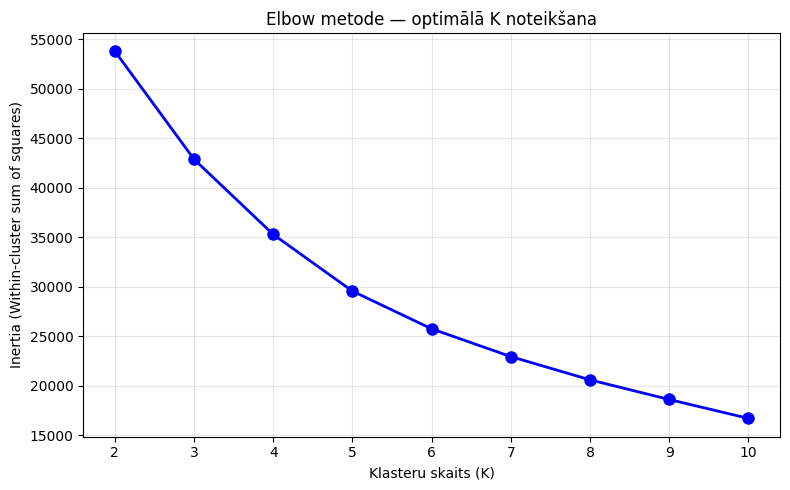

In [4]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow metode — optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 2.2. K vērtības izvēle

**Optimālā klasteru skaita izvēle**

Aplūkojot Elbow metodes grafiku, redzams, ka inercijas samazinājums ir straujš līdz K = 4, bet pēc tam palēninās.
Šis “elkoņa” punkts norāda, ka ar četriem klasteriem tiek panākts labs kompromiss starp modeļa vienkāršību un datu struktūras
atspoguļošanu.

Jāatzīmē, ka K = 5 gadījumā inercijas samazinājums vairs nav būtiski lielāks nekā pie K = 4, līdz ar to papildu klasteris nedod skaidru ieguvumu datu
interpretācijā un palielina modeļa sarežģītību bez praktiska pamatojuma.

Tāpēc turpmākajā analīzē tiek izmantots klasteru skaits K = 4. Jāatzīmē, ka Elbow metodes interpretācija nav pilnībā objektīva, tomēr izvēlētā K vērtība ir praktiski pamatota.

## 3. uzdevums. Veic klasterizāciju un vizualizē

### 3.1. Uztrenē galīgo K-Means modeli

In [5]:
# Izmanto izvēlēto K vērtību (piemēram, 4)
K = 4  # <-- nomainiet uz savu izvēlēto vērtību

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Klasteru sadalījums:")
print(df['Cluster'].value_counts().sort_index())


Klasteru sadalījums:
Cluster
0    9872
1     656
2     931
3     871
Name: count, dtype: int64


### 3.2. Vizualizē klasterus

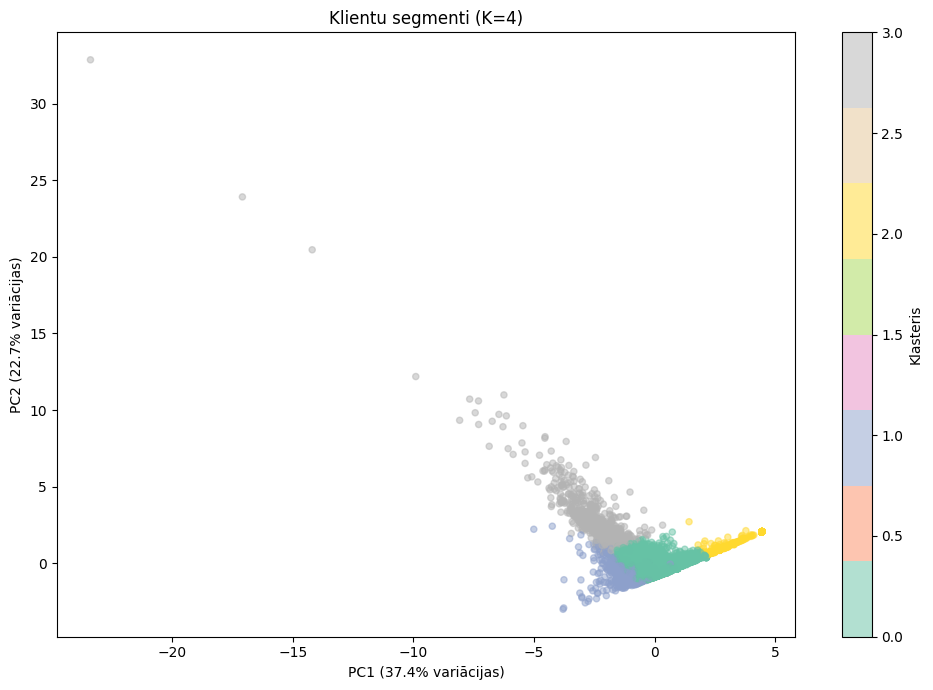

In [6]:
from sklearn.decomposition import PCA

# Samazinām dimensijas līdz 2 vizualizācijai
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)
plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)')
plt.title(f'Klientu segmenti (K={K})')
plt.tight_layout()
plt.show()



**PCA izmantošanas pamatojums**

Principal Component Analysis (PCA) tiek izmantots, lai samazinātu datu dimensiju skaitu līdz divām komponentēm tikai vizualizācijas nolūkiem. PCA saglabā pēc iespējas lielāku sākotnējo datu variāciju, vienlaikus ļaujot klasterus attēlot divdimensiju plaknē.

Svarīgi uzsvērt, ka PCA netiek izmantots klasterizācijas veikšanai, bet tikai rezultātu interpretācijai un vizuālai klasteru atdalāmības novērtēšanai.

### 3.3. Klasteru profili

Klasteru profili (vidējās vērtības):
         Administrative_Duration  Informational_Duration  \
Cluster                                                    
0                          56.28                   13.36   
1                          91.62                   22.46   
2                           1.52                    0.04   
3                         435.57                  319.58   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Cluster                                                               
0                         977.18         0.01       0.03        2.28  
1                        1230.94         0.00       0.01       67.76  
2                          47.20         0.18       0.19        0.00  
3                        4859.98         0.01       0.02        6.44  


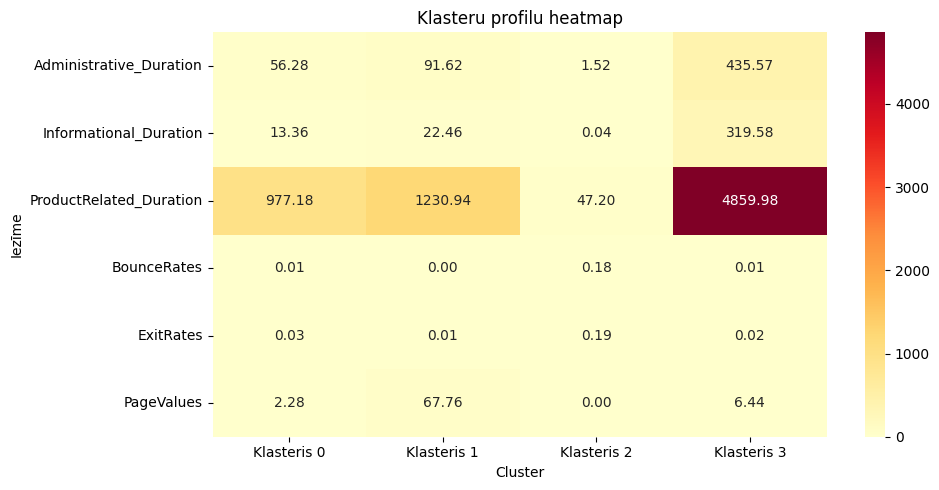

In [7]:
# Katra klastera vidējās vērtības (pirms normalizācijas — lai būtu interpretējami)
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()

cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)
print("Klasteru profili (vidējās vērtības):")
print(cluster_profiles)
# Vizuāli — heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Klasteris {i}' for i in range(K)])
plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()


## 4. uzdevums. Interpretē klasterus biznesa kontekstā

### 4.1. Klasteru raksturojums

Pirkumu īpatsvars pa klasteriem:
Cluster
0    0.115
1    0.791
2    0.005
3    0.281
Name: Revenue, dtype: float64


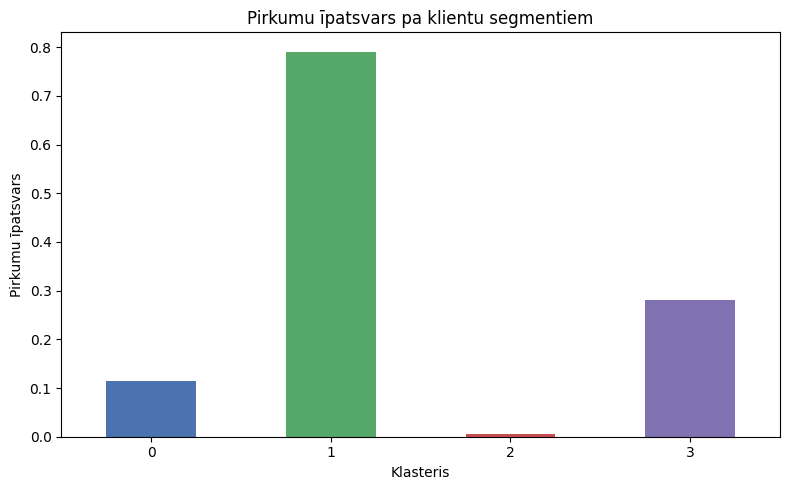

In [8]:
# Cik procentu katra klastera klientu veica pirkumu?
purchase_by_cluster = df.groupby('Cluster')['Revenue'].mean().round(3)
print("Pirkumu īpatsvars pa klasteriem:")
print(purchase_by_cluster)

plt.figure(figsize=(8, 5))
purchase_by_cluster.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Pirkumu īpatsvars pa klientu segmentiem')
plt.xlabel('Klasteris')
plt.ylabel('Pirkumu īpatsvars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



### 4.2. Biznesa interpretācija 

**Klasteru interpretācija**

Analizējot pirkumu īpatsvaru pa klasteriem, redzams, ka klientu grupas būtiski atšķiras pēc pirkuma veikšanas biežuma. Daži klasteri raksturo aktīvākus lietotājus ar lielāku iesaisti un augstāku pirkumu īpatsvaru, savukārt citi klasteri raksturo pasīvākus vai ātri lapu pametošus apmeklētājus.

Šāda segmentācija ļauj uzņēmumam pielāgot mārketinga stratēģijas, piemēram, aktīvākajiem klasteriem piedāvāt personalizētus piedāvājumus, bet pasīvākajiem – uzlabot lietotāja pieredzi vai informatīvo saturu.

Jāatzīmē, ka lielākais klasteris apvieno lielāko daļu pasīvo apmeklētāju, kas ir raksturīgi e‑komercijas datiem, kur tikai neliela daļa lietotāju veic pirkumus.

***Klāsteris 0 – “Mērķtiecīgie, bet piesardzīgie apmeklētāji”***<br>
Raksturojošās vērtības (vidējās):
- Administrative_Duration: 56.28
- Informational_Duration: 13.36
- ProductRelated_Duration: 977.18
- BounceRates: 0.01
- ExitRates: 0.03
- PageValues: 2.28
- Pirkumu īpatsvars (Revenue): ~11.5%
  
Šī klāstera lietotāji pavada ievērojamu laiku produktu lapās, taču relatīvi maz informatīvajās lapās. Zemie atlēcienu un iziešanas rādītāji norāda uz mērķtiecīgu pārlūkošanu, tomēr zemā PageValues vērtība un mērens pirkumu īpatsvars liecina, ka lēmums par pirkumu bieži netiek pieņemts uzreiz.
Biznesa interpretācija: Šis ir perspektīvs segments, kuru iespējams aktivizēt ar akcijām, uzlabotu produktu aprakstu vai cenu salīdzināšanas atvieglojumiem.

***Klāsteris 1 – “Augstas vērtības pircēji”*** <br>
Raksturojošās vērtības (vidējās):
- Administrative_Duration: 91.62
- Informational_Duration: 22.46
- ProductRelated_Duration: 1230.94
- BounceRates: 0.00
- ExitRates: 0.01
- PageValues: 67.76
- Pirkumu īpatsvars (Revenue): ~79.1%

Šis klāsteris raksturo lietotājus ar ļoti augstu iesaisti un skaidru pirkuma nodomu. Tie intensīvi izmanto gan informatīvās, gan produktu lapas, gandrīz nekad neatlec no vietnes un rada ievērojami augstu lapas vērtību.
Biznesa interpretācija: Šis ir uzņēmuma stratēģiski vissvarīgākais klāsteris, uz kuru būtu jāvērš personalizēti piedāvājumi, lojalitātes programmas un “cross‑sell” vai “up‑sell” stratēģijas.

***Klāsteris 2 – “Ātri pametošie apmeklētāji”***<br>
Raksturojošās vērtības (vidējās):
- Administrative_Duration: 1.52
- Informational_Duration: 0.04
- ProductRelated_Duration: 47.20
- BounceRates: 0.18
- ExitRates: 0.19
- PageValues: 0.00
- Pirkumu īpatsvars (Revenue): ~0.5%

Šī klāstera lietotāji pavada minimālu laiku vietnē, ātri pamet lapu un praktiski neveic pirkumus. Augstie BounceRates un ExitRates norāda uz zemu iesaisti vai neatbilstību starp lietotāja gaidām un piedāvāto saturu.
Biznesa interpretācija: Šis klāsteris nav tieši mērķējams pārdošanas aktivitātēm, bet tas ir svarīgs signāls lietotāja pieredzes, mārketinga kanālu vai reklāmu atbilstības izvērtēšanai.

***Klāsteris 3 – “Padziļinātie pētnieki”***<br>
Raksturojošās vērtības (vidējās):
- Administrative_Duration: 435.57
- Informational_Duration: 319.58
- ProductRelated_Duration: 4859.98
- BounceRates: 0.01
- ExitRates: 0.02
- PageValues: 6.44
- Pirkumu īpatsvars (Revenue): ~28.1%

Šī klāstera lietotāji pavada ļoti lielu laiku visos lapu tipos, kas liecina par padziļinātu informācijas meklēšanu un rūpīgu izvērtēšanu. Lai gan pirkumu īpatsvars nav tik augsts kā augstas vērtības pircējiem, tas ir būtiski lielāks nekā pasīvajos segmentos.
Biznesa interpretācija: Šis klāsteris ir piemērots atkārtotām reklāmām, detalizētiem salīdzinājumiem, atsauksmēm un uzticību veidojošam saturam, kas palīdz pārveidot šo augsto iesaisti reālos pirkumos.

**Secinājums.** Klasteru analīze atklāja četrus skaidri atšķirīgus lietotāju segmentus ar būtiskām atšķirībām gan uzvedībā, gan biznesa vērtībā, ļaujot precīzi identificēt augstas vērtības pircējus, potenciālos klientus un pasīvos apmeklētājus.

# B daļa: Modeļu novērtēšana

## 5. uzdevums. Cross-validation

### 5.1. Viens split vs. Cross-validation

In [9]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Ielādē datus
df = pd.read_csv('../week2/shoppers_clean.csv')
y = df['Revenue']
X = df.drop('Revenue', axis=1)

# Viena train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
single_f1 = f1_score(y_test, rf.predict(X_test))
print(f"Viena split F1: {single_f1:.3f}")

# Cross-validation (5-fold)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='f1')
print(f"\n5-fold CV F1 scores: {cv_scores.round(3)}")
print(f"Vidējais F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


Viena split F1: 0.626

5-fold CV F1 scores: [0.656 0.647 0.628 0.542 0.612]
Vidējais F1: 0.617 ± 0.040


## 5.2. Salīdzināšana

### Viena sadalījuma un 5‑fold Cross‑Validation salīdzinājums

**F1 rādītājs** ir viens skaitlis, kas apvieno precizitāti (*precision*) un pilnīgumu (*recall*) (harmoniskais vidējais). Tas ir piemērots, ja klašu sadalījums nav vienmērīgs un svarīgi sabalansēt kļūdainus pozitīvos un palaistus garām pozitīvos gadījumus.

**Viena train/test sadale** dod vienu F1 vērtību, jo modelis tiek apmācīts uz treniņa datiem un novērtēts uz testa datiem. Šis rezultāts var būt jūtīgs pret konkrēto sadalījumu, tāpēc tas var izskatīties nedaudz optimistiskāks vai pesimistiskāks.

**5‑fold Cross‑Validation (CV)** sadala datus 5 daļās (*fold*) un atkārto apmācību/testēšanu 5 reizes: katru reizi cita daļa ir tests, bet pārējās – treniņš. Rezultātā iegūst 5 F1 vērtības, kuru **vidējais F1** raksturo sagaidāmo modeļa veiktspēju stabilāk nekā viena sadale.

**Standartnovirze (±)** raksturo, cik ļoti F1 vērtības svārstās starp fold, t.i., modeļa stabilitāti dažādās datu apakškopās. Tā nav “kļūda”, bet veiktspējas variācija.

Konkrētajā gadījumā viena sadalījuma F1 ir **0.626**, bet 5‑fold CV vidējais F1 ir **0.617 ± 0.040**. Tas norāda, ka viena sadale sniedza nedaudz optimistiskāku novērtējumu, savukārt CV rezultāts ir metodoloģiski uzticamāks, jo balstās uz vairākām neatkarīgām datu sadalēm. Standartnovirze **±0.040** liecina par mērenām svārstībām starp fold, tātad modelis kopumā darbojas samērā konsekventi.


## 6. uzdevums. Pipeline

### 6.1. Kā veidot Pipeline

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Pipeline — scaler + modelis vienā
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

# Cross-validation ar pipeline
cv_scores_pipe = cross_val_score(pipe, X, y, cv=5, scoring='f1')
print(f"Pipeline CV F1: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}")


Pipeline CV F1: 0.619 ± 0.041


### 6.2. Pipeline nozīme

### Pipeline izmantošana un data leakage riska novēršana

Data leakage jeb datu noplūde rodas situācijās, kad informācija no testēšanas datiem tieši vai netieši tiek izmantota modeļa apmācības procesā. Tas noved pie pārlieku optimistiskiem veiktspējas novērtējumiem, jo modelis tiek ietekmēts ar informāciju, kas tam reālajā lietojumā nebūtu pieejama.

Iepriekšējā pieejā datu normalizācija tika veikta pirms modeļa novērtēšanas visai datu kopai kopumā. Šādā gadījumā normalizācijas parametri (vidējās vērtības un standartnovirzes) tiek aprēķināti, izmantojot arī testēšanas datus, kas rada potenciālu data leakage risku un var mākslīgi uzlabot modeļa rezultātus.

Izmantojot `Pipeline`, datu apstrāde (normalizācija) un modeļa apmācība tiek apvienotas vienā struktūrā. Tādējādi katrā Cross‑Validation iterācijā
`StandardScaler` tiek apmācīts **tikai uz attiecīgās treniņa datu apakškopas**, bet testēšanas dati tiek skalēti, izmantojot treniņa datos iegūtos parametrus. Tas pilnībā novērš data leakage risku.

### Pipeline Cross‑Validation rezultātu interpretācija

Pipeline Cross‑Validation rezultāts rāda vidējo F1 rādītāju **0.619** ar standartnovirzi **±0.041**, kas raksturo modeļa veiktspēju gadījumā, kad visi
datu apstrādes soļi tiek veikti metodoloģiski korekti.

Salīdzinot ar Cross‑Validation rezultātiem bez Pipeline (F1 ≈ 0.617 ± 0.040), redzams, ka veiktspēja ir ļoti līdzīga. Tas norāda, ka šajā konkrētajā gadījumā data leakage ietekme nebija būtiska, tomēr Pipeline pieeja garantē, ka rezultāti precīzi atspoguļo modeļa spēju vispārināt uz jauniem
datiem.

Standartnovirze **±0.041** liecina par stabilu modeļa darbību dažādās datu sadalēs. Svarīgākais Pipeline ieguvums nav F1 rādītāja palielinājums, bet gan metodoloģiski uzticams un drošs modeļa novērtējums, kas ir būtisks reālā pielietojuma kontekstā.

## 7. uzdevums. GridSearchCV

### 7.1. Automātiska parametru meklēšana

In [11]:
from sklearn.model_selection import GridSearchCV

# Pipeline, kam meklēsim labākos parametrus
pipe_grid = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parametru tīkls
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

# GridSearchCV — automātiska meklēšana + cross-validation
grid = GridSearchCV(pipe_grid, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākais CV F1: {grid.best_score_:.3f}")
print(f"Testa F1: {f1_score(y_test, grid.predict(X_test)):.3f}")


Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 200}
Labākais CV F1: 0.648
Testa F1: 0.633


### 7.2. Vizualizācija

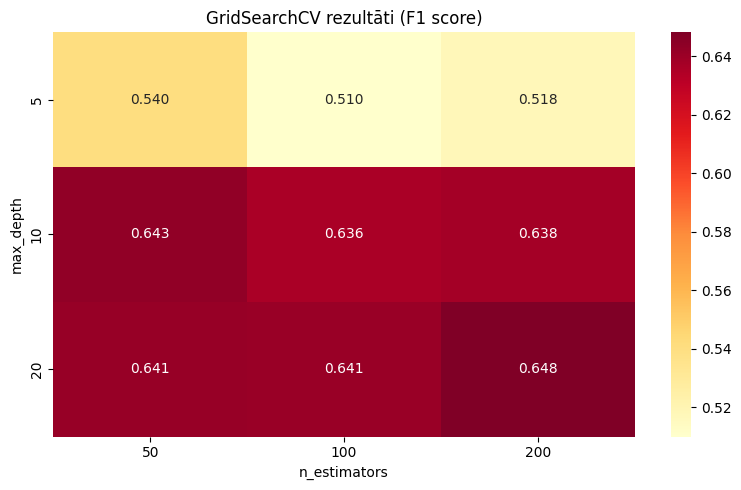

In [12]:
# Vizualizē GridSearch rezultātus
results = pd.DataFrame(grid.cv_results_)
pivot = results.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

import seaborn as sns
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('GridSearchCV rezultāti (F1 score)')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()


### 7.3. Analīze

### GridSearchCV rezultātu analīze un praktiskais izvērtējums

GridSearchCV rezultātā tika identificēta optimāla hiperparametru kombinācija – `max_depth = 20` un `n_estimators = 200`, kas nodrošina augstāko vidējo F1 rādītāju Cross‑Validation ietvaros. Šī parametru izvēle norāda, ka dziļāks Random Forest modelis ar lielāku koku skaitu spēj labāk uztvert sarežģītās un nelineārās sakarības datos.

Labākais vidējais Cross‑Validation F1 rādītājs ir **0.648**, kas ir neliels, bet konsekvents uzlabojums salīdzinājumā ar iepriekš izmantoto modeli bez optimizētiem parametriem. Testa kopā iegūtais F1 rādītājs ir **0.633**, kas ir nedaudz zemāks par CV rezultātu, bet atrodas saprātīgā tuvumā tam, kas norāda uz labu modeļa vispārināšanas spēju un pārmācīšanās neesamību.

Heatmap vizualizācija ļauj salīdzināt dažādu parametru kombināciju veiktspēju un parāda, ka F1 rādītāja uzlabojums, palielinot `n_estimators` un `max_depth`, ir pakāpenisks, nevis straujš. Tas norāda, ka veiktspējas pieaugums ir stabils, bet salīdzinoši neliels.

No praktiskā viedokļa ir būtiski izvērtēt, vai šāds uzlabojums attaisno papildu skaitļošanas izmaksas. GridSearchCV pieprasa būtiski vairāk laika un resursu, jo tiek trenēti daudzi modeļi ar dažādām parametru kombinācijām. Gadījumos, kad veiktspējas pieaugums ir neliels, vienkāršāks modelis var būt pietiekami efektīvs praktiskā lietojumā.

Tādējādi GridSearchCV galvenā vērtība šajā uzdevumā nav tikai F1 rādītāja palielināšana, bet arī apstiprinājums tam, ka sākotnējais modelis bija tuvu
optimālam, kā arī iespēja pieņemt pamatotus lēmumus starp modeļa sarežģītību, skaitļošanas izmaksām un praktisko ieguvumu.

## SECINĀJUMI

Šajā darbā tika secīgi izpildīti klasterizācijas un modeļu novērtēšanas uzdevuma galvenie soļi, sākot ar datu sagatavošanu un normalizāciju un beidzot ar modeļu validāciju un optimizāciju. Klasterizācijas rezultātā tika identificēti četri klientu segmenti ar atšķirīgu uzvedību un biznesa vērtību, kas ļauj formulēt praktiskas rekomendācijas.
Modeļu novērtēšanas daļā Cross‑Validation tika izmantots stabilākam veiktspējas novērtējumam nekā viena train/test sadale. Pipeline nodrošināja korektu datu apstrādi un novērsa data leakage risku, savukārt GridSearchCV ļāva izvērtēt hiperparametru ietekmi uz modeļa veiktspēju.
Darba rezultāti parāda, ka izmantotās datu sagatavošanas, validācijas un modeļu optimizācijas metodes ļauj iegūt korektu un interpretējamu mašīnmācīšanās risinājumu.